In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
import numpy as np
import matplotlib.pyplot as plt

In [2]:
torch.cuda.is_available()

True

In [3]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Используется: {device}")

Используется: cuda


In [4]:
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.1307,), (0.3081,))
])

In [5]:
train = DataLoader(
    datasets.MNIST('./data', train=True, download=True, transform=transform),
    batch_size=64, shuffle=True
)

test = DataLoader(
    datasets.MNIST('./data', train=False, download=True, transform=transform),
    batch_size=64, shuffle=False
)

In [6]:
class CNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv1 = nn.Conv2d(1, 32, 3, padding=1)
        self.conv2 = nn.Conv2d(32, 64, 3, padding=1)
        self.pool = nn.MaxPool2d(2)
        self.fc1 = nn.Linear(64 * 7 * 7, 128)
        self.fc2 = nn.Linear(128, 10)
        self.dropout = nn.Dropout(0.25)
        self.relu = nn.ReLU()
    
    def forward(self, x):
        x = self.pool(self.relu(self.conv1(x)))
        x = self.pool(self.relu(self.conv2(x)))
        x = x.view(x.size(0), -1)
        x = self.relu(self.fc1(x))
        x = self.dropout(x)
        x = self.fc2(x)
        return x

model = CNN().to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters())

In [7]:
for epoch in range(5):
    model.train()
    for data, target in train:
        data, target = data.to(device), target.to(device)
        optimizer.zero_grad()
        loss = criterion(model(data), target)
        loss.backward()
        optimizer.step()
    
    model.eval()
    correct = 0
    with torch.no_grad():
        for data, target in test:
            data, target = data.to(device), target.to(device)
            pred = model(data).argmax(1)
            correct += (pred == target).sum().item()
    
    acc = 100 * correct / len(test.dataset)
    print(f"Epoch {epoch+1}, Accuracy: {acc:.2f}%")

Epoch 1, Accuracy: 98.42%
Epoch 2, Accuracy: 98.83%
Epoch 3, Accuracy: 99.25%
Epoch 4, Accuracy: 99.19%
Epoch 5, Accuracy: 99.22%


In [9]:
model.eval()
predictions = []
images = []
true_labels = []

with torch.no_grad():
    for data, target in test:
        data = data.to(device)
        pred = model(data).argmax(1)
        predictions.extend(pred.cpu().numpy())
        images.extend(data.cpu())
        true_labels.extend(target.numpy())
        
        if len(predictions) >= 10:
            break

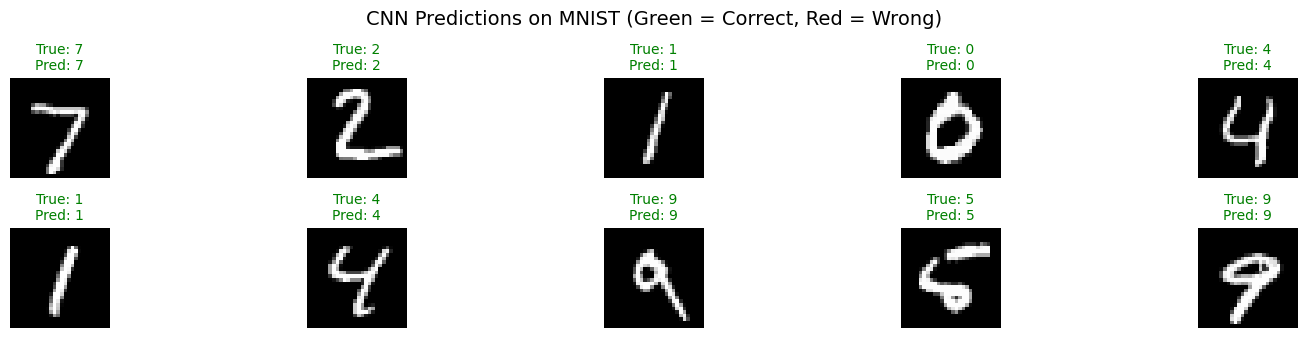

In [10]:
plt.figure(figsize=(15, 8))
for i in range(10):
    plt.subplot(5, 5, i+1)
    plt.imshow(images[i].squeeze(), cmap='gray')
    color = 'green' if predictions[i] == true_labels[i] else 'red'
    plt.title(f'True: {true_labels[i]}\nPred: {predictions[i]}', color=color, fontsize=10)
    plt.axis('off')

plt.suptitle('CNN Predictions on MNIST (Green = Correct, Red = Wrong)', fontsize=14)
plt.tight_layout()
plt.savefig('mnist_cnn_predictions.png', dpi=300, bbox_inches='tight')
plt.show()